In [2]:
# 1. data handling & math
import pandas as pd  # DataFrame load
import numpy as np  # array aur mathmatical calculation

import scipy.stats as stats  # Statistical test aur Q-Q plot ke liye

# 2. Data Visualization
import matplotlib.pyplot as plt  # basic plots aur graph
import seaborn as sns           # advance statical graph

# 3. Model Evalution & Splitting
from sklearn.model_selection import train_test_split  # data ko train aur test main batne ke liye
from sklearn.metrics import accuracy_score            # model ki accuracy
from sklearn.model_selection import cross_val_score  # cross-validation se reliability check karne ke liye

# mashine learning model
from sklearn.linear_model import LogisticRegression  # binary classification algorithm
from sklearn.tree import DecisionTreeClassifier  # tree based classification model

# feature engineering / transformation
from sklearn.preprocessing import FunctionTransformer # custom function (log,sqrt) apply
from sklearn.compose import ColumnTransformer # 

In [5]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [10]:
df.fillna({'Age':df['Age'].mean()},inplace=True)

In [11]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [12]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [15]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

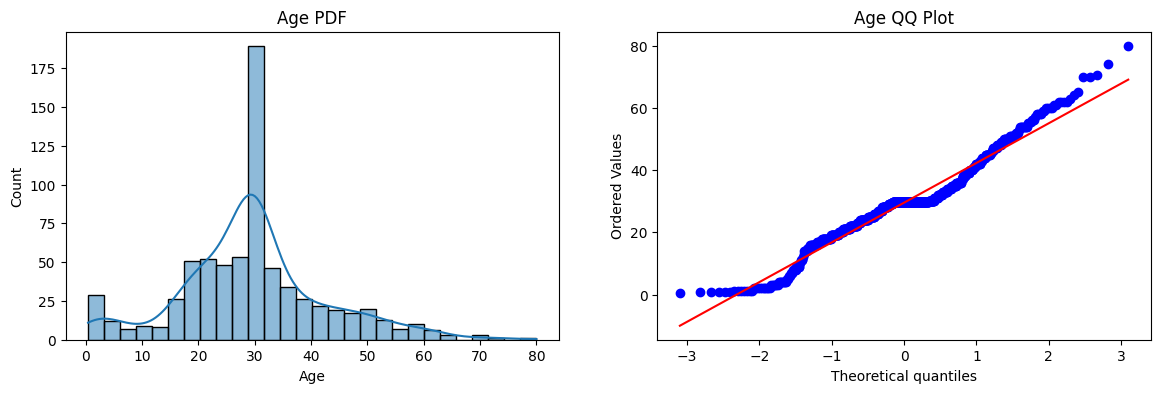

In [21]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm',plot=plt)
plt.title('Age QQ Plot')

plt.show()

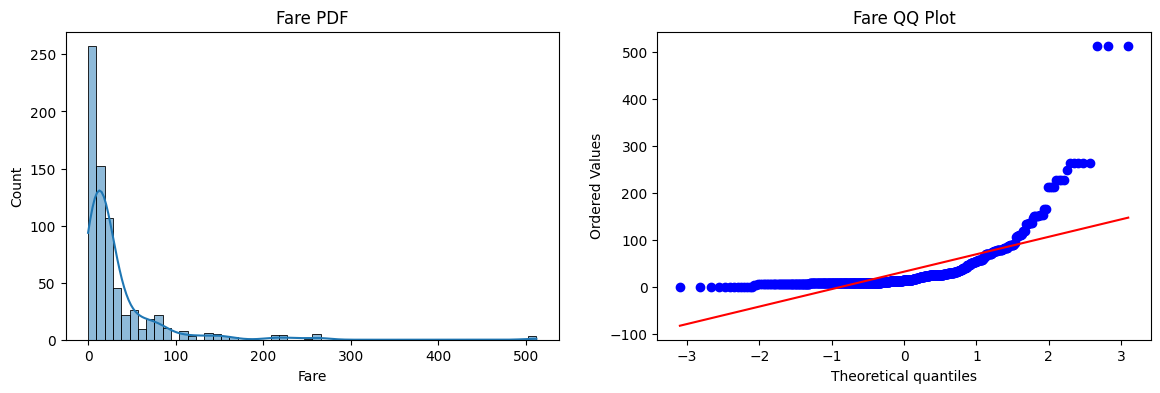

In [22]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm',plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [23]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [25]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test) # Logistic regression
y_pred1 = clf2.predict(X_test) # decision tree

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.664804469273743


In [26]:
trf = FunctionTransformer(func=np.log1p)

In [27]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [33]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6815642458100558


In [36]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6577528089887641


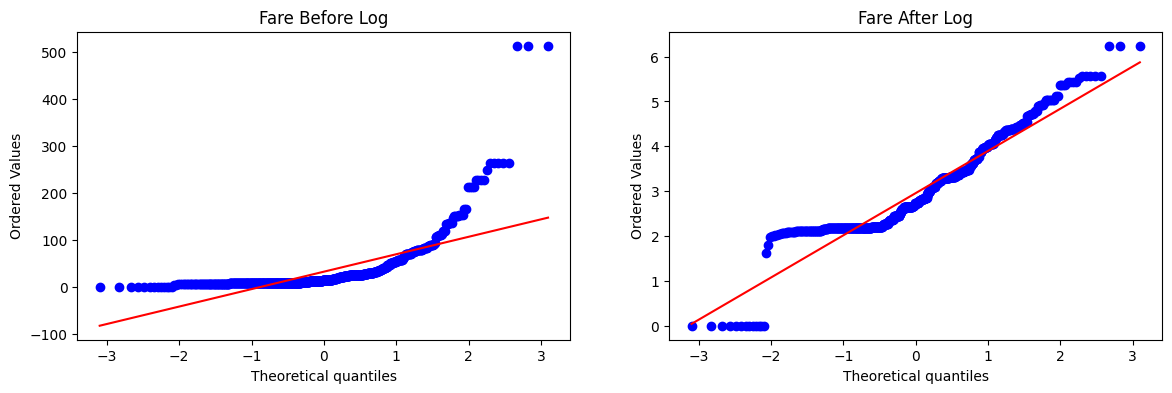

In [38]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title("Fare Before Log")

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist="norm",plot=plt)
plt.title("Fare After Log")

plt.show()

In [43]:
trf2 = ColumnTransformer([('Log',FunctionTransformer(np.log1p),['Fare'])],remainder="passthrough")

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [45]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6759776536312849


In [51]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('transform',FunctionTransformer(transform),['Fare'])],remainder="passthrough")

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm",plot=plt)
    plt.title("Fare Before Trasform")

    
    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm",plot=plt)
    plt.title("Fare After Trasform")

    plt.show()

Accuracy 0.6589013732833957


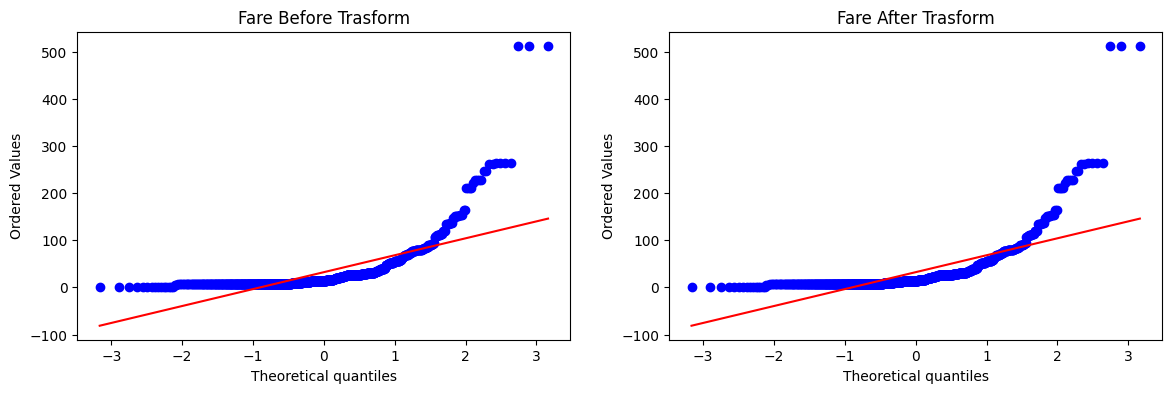

In [52]:
apply_transform(lambda X: X)

Accuracy 0.6431335830212235


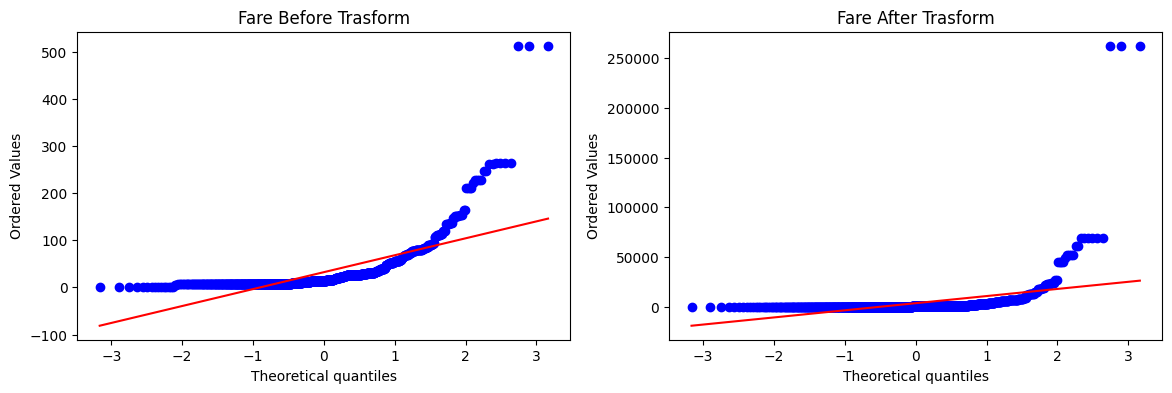

In [53]:
apply_transform(lambda X: X**2)

Accuracy 0.6589013732833957


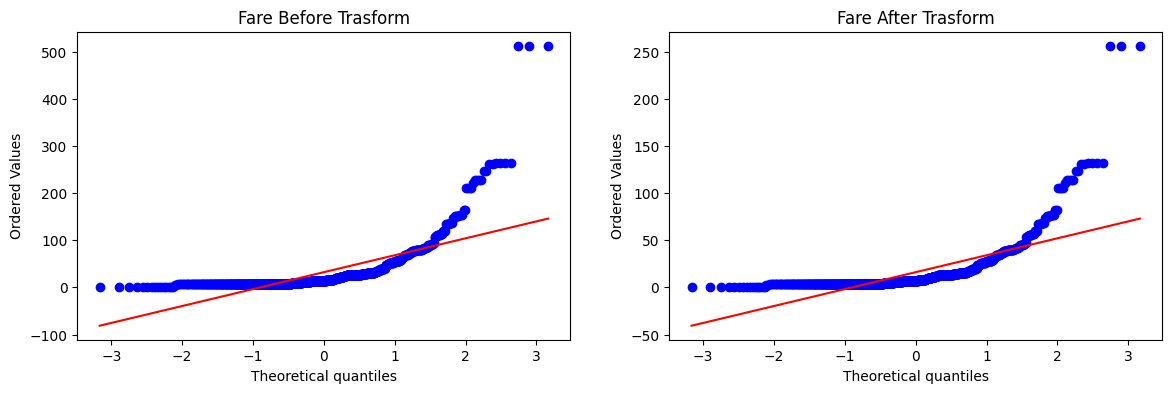

In [56]:
apply_transform(lambda X: X**1/2)

Accuracy 0.61729088639201


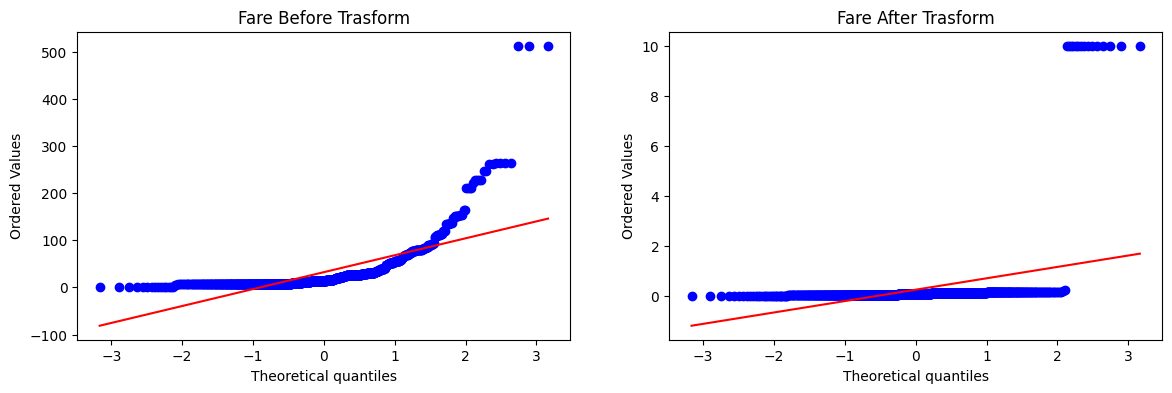

In [59]:
apply_transform(lambda X: 1/(X+0.1))

Accuracy 0.6195131086142323


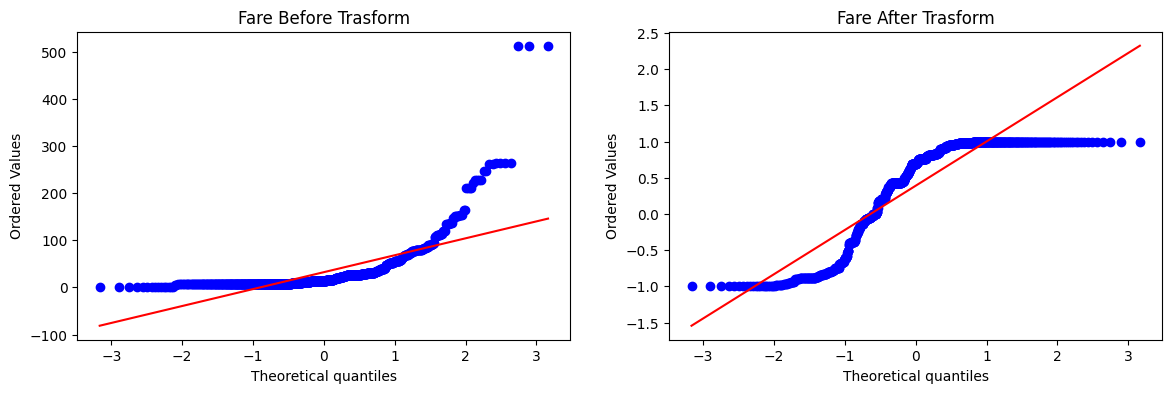

In [60]:
apply_transform(np.sin)